# Imports

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import re
from collections import Counter
import umap
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
from transformers import AutoTokenizer, AutoModel


c:\git_clones\tech_challenge_illuin_technology\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [3]:
parent_dir = os.path.dirname(os.getcwd())
data_dir = os.path.join(parent_dir, 'data')
print(f"Data directory: {data_dir}")
data = pd.read_json(os.path.join(data_dir, 'dataset.json'), lines=True)
data.head()

Data directory: c:\git_clones\tech_challenge_illuin_technology\data


,prob_desc_time_limit,prob_desc_sample_outputs,src_uid,prob_desc_notes,prob_desc_description,prob_desc_output_spec,prob_desc_input_spec,prob_desc_output_to,prob_desc_input_from,lang,...,difficulty,file_name,code_uid,prob_desc_memory_limit,prob_desc_sample_inputs,exec_outcome,source_code,prob_desc_created_at,tags,hidden_unit_tests
0,2 seconds,"[""2\n2 4\n3 3\n3 1""]",591372383cf3624f69793c41370022de,NaN,"Numbers $$$1, 2, 3, \dots n$$$ (each integer f...","For each test case, in the first line, print t...",The first line contains one integer $$$t$$$ ($...,standard output,standard input,Python 3,...,1000.0,train_000.jsonl,88084dde61bbebdebe163309a2bda179,256 megabytes,"[""1\n4""]",PASSED,\ndef ii(): return int(input())\ndef mi(): ret...,2020-10-11 09:05:00,"[greedy, constructive algorithms, math, implem...",
1,3 seconds,"[""4\n10\n4\n0""]",afcd41492158e68095b01ff1e88c3dd4,"NoteIn the first test case of the example, the...","There are $$$n$$$ positive integers $$$a_1, a_...",For $$$t$$$ test cases print the answers in th...,The first line of the input contains one integ...,standard output,standard input,Python 3,...,1200.0,train_000.jsonl,df0e2ae03513f2b9280e19a1df6c8d84,256 megabytes,"[""4\n6\n40 6 40 3 20 1\n1\n1024\n4\n2 4 8 16\n...",PASSED,a = int(input())\nfor i in range(a):\n f = ...,2019-12-14 11:05:00,"[number theory, greedy]",
2,2 seconds,"[""5"", ""16"", ""18""]",e52ec2fa5bcf5d2027d57b0694b4e15a,NoteIn the first example it is possible to con...,You are given an undirected graph consisting o...,Print one integer — the minimum number of coin...,The first line contains two integers $$$n$$$ a...,standard output,standard input,Python 3,...,1900.0,train_000.jsonl,d045b0ecd6aaad78a2574780f55d22a1,256 megabytes,"[""3 2\n1 3 3\n2 3 5\n2 1 1"", ""4 0\n1 3 3 7"", ""...",PASSED,def read_nums():\n return [int(x) for x in ...,2018-12-27 14:35:00,"[dsu, greedy, graphs]",
3,1 second,"[""2\n5000 9\n1\n7 \n4\n800 70 6 9000 \n1\n1000...",cd2519f4a7888b2c292f05c64a9db13a,NaN,A positive (strictly greater than zero) intege...,Print $$$t$$$ answers to the test cases. Each ...,The first line contains an integer $$$t$$$ ($$...,standard output,standard input,PyPy 3,...,800.0,train_000.jsonl,52a2313fac7f87cb6696ab7b8e4dc447,256 megabytes,"[""5\n5009\n7\n9876\n10000\n10""]",PASSED,t = int(input())\nfor i in range(t):\n canP...,2020-05-22 13:35:00,"[implementation, math]",
4,1 second,"[""9"", ""14""]",d7fe15a027750c004e4f50175e1e20d2,NaN,"Polycarp is working on a new project called ""P...",Print a single number — answer to the problem.,Input file will contain not more than 100 comm...,standard output,standard input,Python 2,...,1000.0,train_005.jsonl,68e7ea5367d538b53e8e36e804665b20,64 megabytes,"[""+Mike\nMike:hello\n+Kate\n+Dmitry\n-Dmitry\n...",PASSED,import sys\nz=x=0\nfor s in sys.stdin:\n\tif s...,2010-03-20 16:00:00,[implementation],


# EDA

## Analyse de forme

* **Variable target :** 
    * T=38 tags individuels, certains très fréquents (greedy, implementation, math)
    * Cardinalité des tags (le nombre moyen de tags par exemple) : 2.8
    * Densité des tags (le nombre moyen de tags par exemple divisé par le nombre total de tags T) : 0.074
    * Diversité des tags : 1907 combinaisons distinctes de tags, certains très fréquents ([implementation], [math], [greedy]). 
    * Comme suggéré par l'énoncé, je vais me concentrer sur les tags **'math', 'graphs','strings','number theory','trees','geometry','games','probabilities'**
* **Lignes et colonnes :** (4982, 21)
* **Types de variables :** 17 qualitatives, 3 quantitatives
* **Analyse de valeurs manquantes :** hidden_unit_tests is an empty string, prob_desc_notes : 27%, quelques valeurs manquantes pour prob_desc_output_spec, prob_desc_input_spec et difficulty

In [144]:
df = data.copy()

In [145]:
df.shape

(4982, 21)

<Axes: >

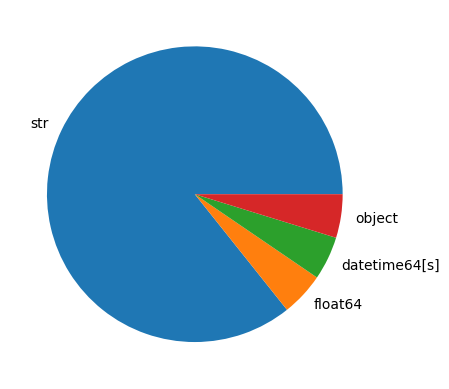

In [146]:
df.dtypes.value_counts().plot.pie()

<Axes: >

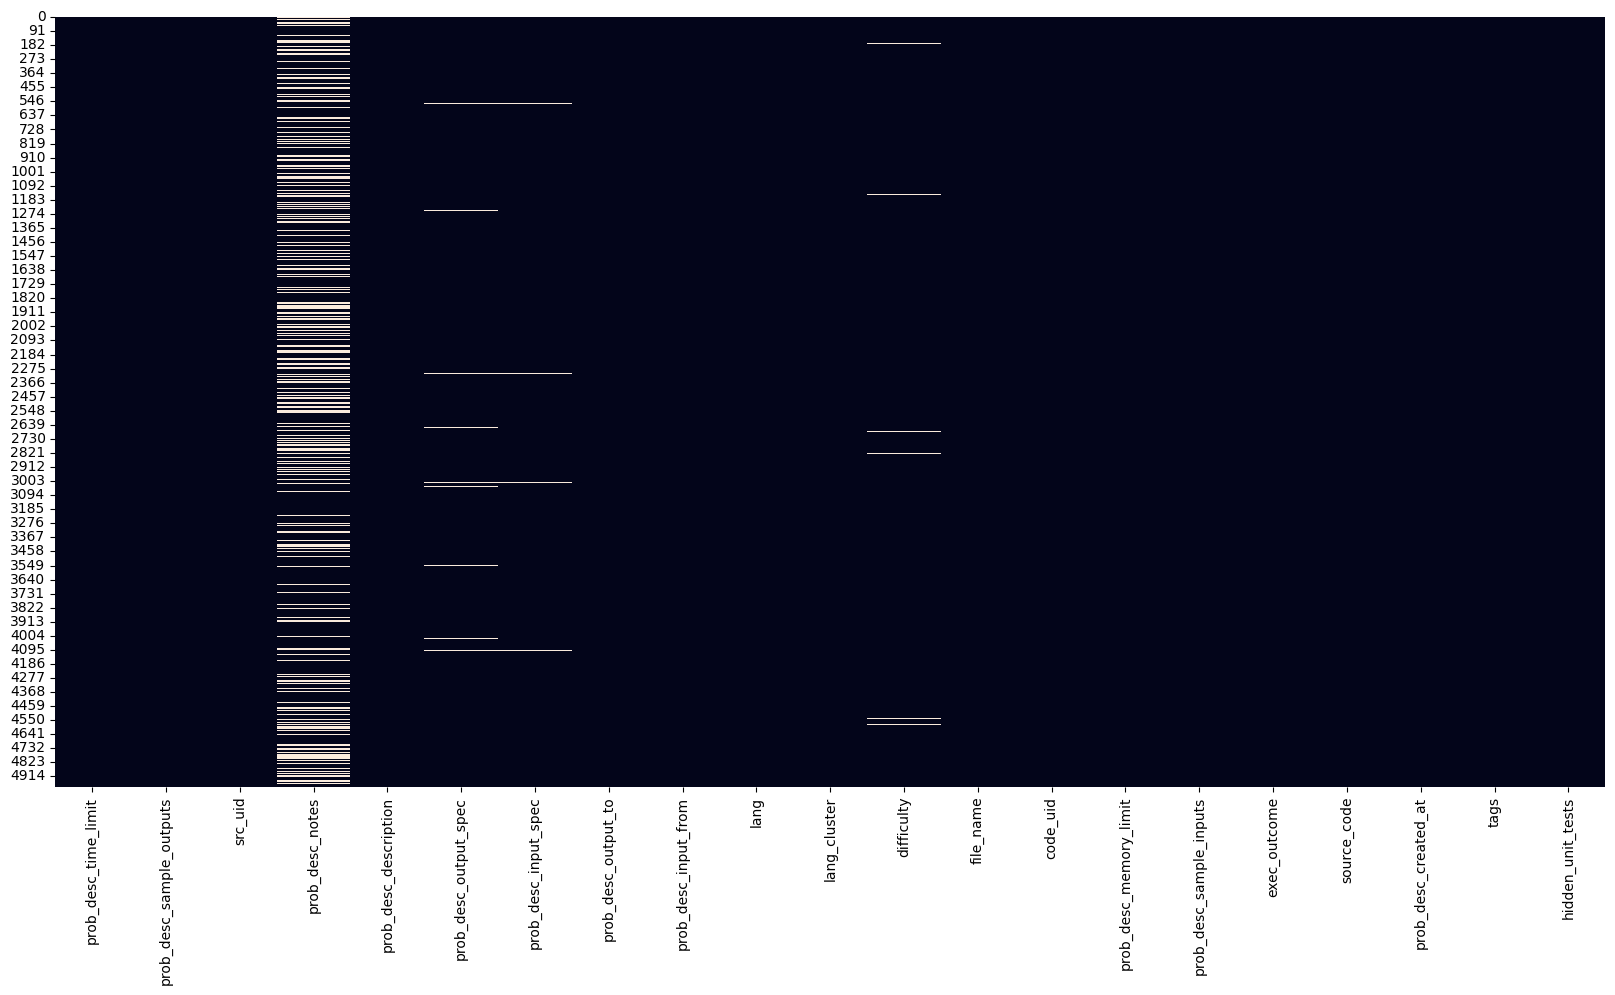

In [147]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

<Axes: title={'center': 'Percentage of NaN per Column'}>

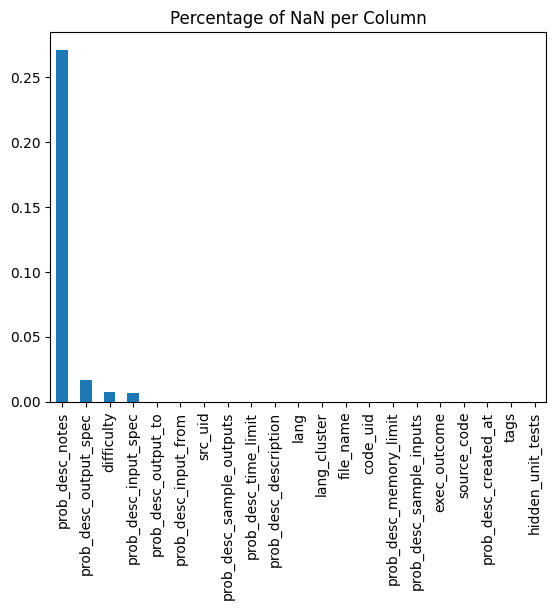

In [148]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=False).plot.bar(title="Percentage of NaN per Column")

In [149]:
df['hidden_unit_tests'].nunique() # contient une seule valeur

1

In [150]:
df['lang_cluster'].nunique() # contient une seule valeur

1

In [151]:
df['exec_outcome'].nunique() # contient une seule valeur

1

In [152]:
def tag_stats(df):
    tags_normalized = (
    df["tags"]
    .dropna()
    .apply(
        lambda x: tuple(x)
        if isinstance(x, list)
        else tuple(ast.literal_eval(x))
        if isinstance(x, str) and x.startswith("[")
        else (x,)
    )
)   
    tags_exploded = (
        df["tags"]
        .dropna()
        .apply(lambda x: x if isinstance(x, list) else ast.literal_eval(x) if isinstance(x, str) and x.startswith("[") else [x])
        .explode()
    )

    tag_distribution = tags_exploded.value_counts().plot.bar(figsize=(12, 6), title="Distribution of Tags")
    display(tag_distribution)

    unique_combinations_distribution = tags_normalized.value_counts().rename_axis("tag").reset_index(name="count")
    display(unique_combinations_distribution)

    unique_tags = len(tags_exploded.unique())

    # Tag cardinality: average number of individual tags per example
    tag_cardinality = tags_normalized.apply(len).mean()

    # Tag density: average number of individual tags per example divided by the total number of individual tags
    tag_density = tag_cardinality / unique_tags

    # Tag diversity: unique tag combinations
    tag_diversity = len(tags_normalized.unique())
    
    return float(round(tag_cardinality, 3)), float(round(tag_density, 3)), tag_diversity

<Axes: title={'center': 'Distribution of Tags'}, xlabel='tags'>

,tag,count
0,"(implementation,)",273
1,"(math,)",123
2,"(greedy,)",120
3,"(implementation, math)",76
4,"(dp,)",75
...,...,...
1902,"(constructive algorithms, implementation, gree...",1
1903,"(dp, hashing, data structures, binary search, ...",1
1904,"(two pointers, sortings, greedy, math)",1
1905,"(dp, two pointers, greedy, brute force)",1


(2.8, 0.074, 1907)

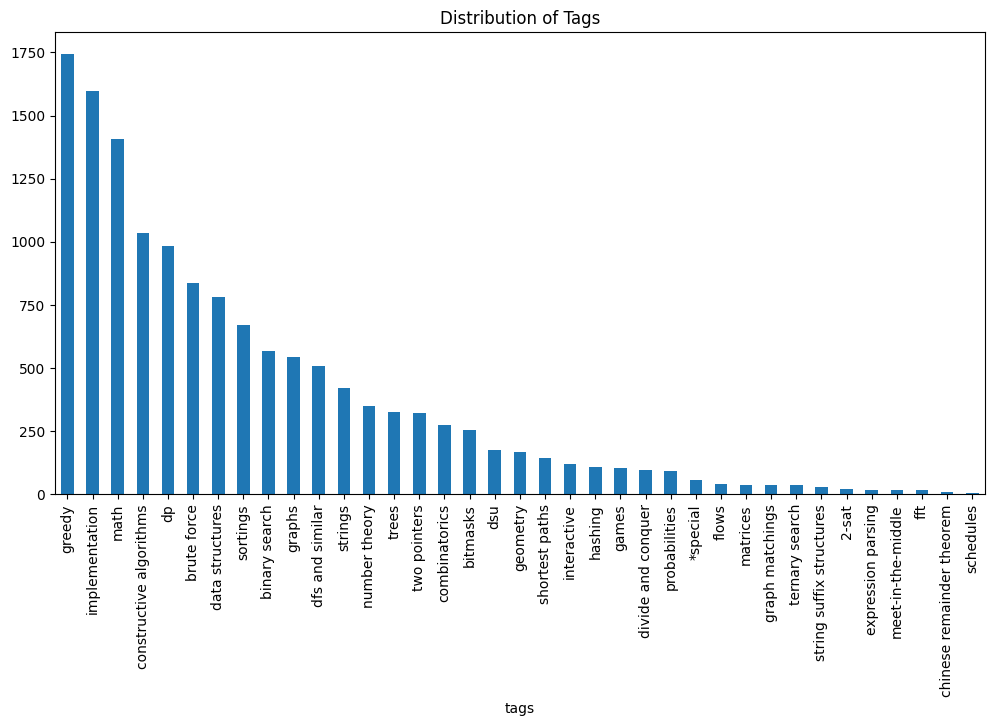

In [153]:
tag_stats(df)

## Analyse de fond

* Signification des variables : 
len, embedding et frequent words 
    * prob_desc_description :
    * prob_desc_input_spec :
    * prob_desc_output_spec :
    * source_code :
* Relation Variables / Target :
    * Une dépendance entre tags et difficulty 
    * Les features time_limit et memory_limit sont non significatives
    * Relation entre variables textuelles et targets ????

### Elimination des colonnes inutiles

In [154]:
df.drop(columns=['hidden_unit_tests', 'src_uid','code_uid','prob_desc_created_at','prob_desc_output_to','prob_desc_input_from','exec_outcome','file_name','lang','lang_cluster'], inplace=True) # des colonnes inutiles

In [155]:
df.head()

,prob_desc_time_limit,prob_desc_sample_outputs,prob_desc_notes,prob_desc_description,prob_desc_output_spec,prob_desc_input_spec,difficulty,prob_desc_memory_limit,prob_desc_sample_inputs,source_code,tags
0,2 seconds,"[""2\n2 4\n3 3\n3 1""]",NaN,"Numbers $$$1, 2, 3, \dots n$$$ (each integer f...","For each test case, in the first line, print t...",The first line contains one integer $$$t$$$ ($...,1000.0,256 megabytes,"[""1\n4""]",\ndef ii(): return int(input())\ndef mi(): ret...,"[greedy, constructive algorithms, math, implem..."
1,3 seconds,"[""4\n10\n4\n0""]","NoteIn the first test case of the example, the...","There are $$$n$$$ positive integers $$$a_1, a_...",For $$$t$$$ test cases print the answers in th...,The first line of the input contains one integ...,1200.0,256 megabytes,"[""4\n6\n40 6 40 3 20 1\n1\n1024\n4\n2 4 8 16\n...",a = int(input())\nfor i in range(a):\n f = ...,"[number theory, greedy]"
2,2 seconds,"[""5"", ""16"", ""18""]",NoteIn the first example it is possible to con...,You are given an undirected graph consisting o...,Print one integer — the minimum number of coin...,The first line contains two integers $$$n$$$ a...,1900.0,256 megabytes,"[""3 2\n1 3 3\n2 3 5\n2 1 1"", ""4 0\n1 3 3 7"", ""...",def read_nums():\n return [int(x) for x in ...,"[dsu, greedy, graphs]"
3,1 second,"[""2\n5000 9\n1\n7 \n4\n800 70 6 9000 \n1\n1000...",NaN,A positive (strictly greater than zero) intege...,Print $$$t$$$ answers to the test cases. Each ...,The first line contains an integer $$$t$$$ ($$...,800.0,256 megabytes,"[""5\n5009\n7\n9876\n10000\n10""]",t = int(input())\nfor i in range(t):\n canP...,"[implementation, math]"
4,1 second,"[""9"", ""14""]",NaN,"Polycarp is working on a new project called ""P...",Print a single number — answer to the problem.,Input file will contain not more than 100 comm...,1000.0,64 megabytes,"[""+Mike\nMike:hello\n+Kate\n+Dmitry\n-Dmitry\n...",import sys\nz=x=0\nfor s in sys.stdin:\n\tif s...,[implementation]


In [156]:
df.shape

(4982, 11)

### Elimination des tags difficiles

In [157]:
# Filtrer les tags pour ne garder que ceux d'intérêt
tags_to_keep = ['math', 'graphs', 'strings', 'number theory', 'trees', 'geometry', 'games', 'probabilities']
def filter_tags(x):

    if isinstance(x, list):
        tags = x
    elif isinstance(x, str) and x.startswith("["):
        try:
            tags = ast.literal_eval(x)
        except Exception:
            tags = [x]
    else:
        tags = [x]
    return list(str(tag) for tag in tags if str(tag) in tags_to_keep)

In [158]:
df['tags'] = df['tags'].apply(filter_tags)
# Supprimer les exemples sans tags d'intérêt
df = df[df['tags'].map(len) > 0]

In [159]:
df.head()

,prob_desc_time_limit,prob_desc_sample_outputs,prob_desc_notes,prob_desc_description,prob_desc_output_spec,prob_desc_input_spec,difficulty,prob_desc_memory_limit,prob_desc_sample_inputs,source_code,tags
0,2 seconds,"[""2\n2 4\n3 3\n3 1""]",NaN,"Numbers $$$1, 2, 3, \dots n$$$ (each integer f...","For each test case, in the first line, print t...",The first line contains one integer $$$t$$$ ($...,1000.0,256 megabytes,"[""1\n4""]",\ndef ii(): return int(input())\ndef mi(): ret...,[math]
1,3 seconds,"[""4\n10\n4\n0""]","NoteIn the first test case of the example, the...","There are $$$n$$$ positive integers $$$a_1, a_...",For $$$t$$$ test cases print the answers in th...,The first line of the input contains one integ...,1200.0,256 megabytes,"[""4\n6\n40 6 40 3 20 1\n1\n1024\n4\n2 4 8 16\n...",a = int(input())\nfor i in range(a):\n f = ...,[number theory]
2,2 seconds,"[""5"", ""16"", ""18""]",NoteIn the first example it is possible to con...,You are given an undirected graph consisting o...,Print one integer — the minimum number of coin...,The first line contains two integers $$$n$$$ a...,1900.0,256 megabytes,"[""3 2\n1 3 3\n2 3 5\n2 1 1"", ""4 0\n1 3 3 7"", ""...",def read_nums():\n return [int(x) for x in ...,[graphs]
3,1 second,"[""2\n5000 9\n1\n7 \n4\n800 70 6 9000 \n1\n1000...",NaN,A positive (strictly greater than zero) intege...,Print $$$t$$$ answers to the test cases. Each ...,The first line contains an integer $$$t$$$ ($$...,800.0,256 megabytes,"[""5\n5009\n7\n9876\n10000\n10""]",t = int(input())\nfor i in range(t):\n canP...,[math]
5,1 second,"[""1"", ""0""]",NoteThe first test case corresponds to the tre...,You are given a tree with $$$n$$$ vertices. Yo...,Print a single integer — the minimum number o...,The first line contains an integer $$$n$$$ ($$...,2800.0,256 megabytes,"[""6\n4 5\n2 6\n3 2\n1 2\n2 4"", ""4\n2 4\n4 1\n3...",import sys\nfrom collections import defaultdic...,"[graphs, trees]"


In [160]:
df.shape

(2678, 11)

<Axes: title={'center': 'Distribution of Tags'}, xlabel='tags'>

,tag,count
0,"(math,)",928
1,"(strings,)",353
2,"(graphs,)",332
3,"(trees,)",147
4,"(number theory, math)",139
...,...,...
72,"(games, graphs, math, number theory, trees)",1
73,"(geometry, graphs, trees)",1
74,"(games, math, strings)",1
75,"(games, math, trees)",1


(1.273, 0.159, 77)

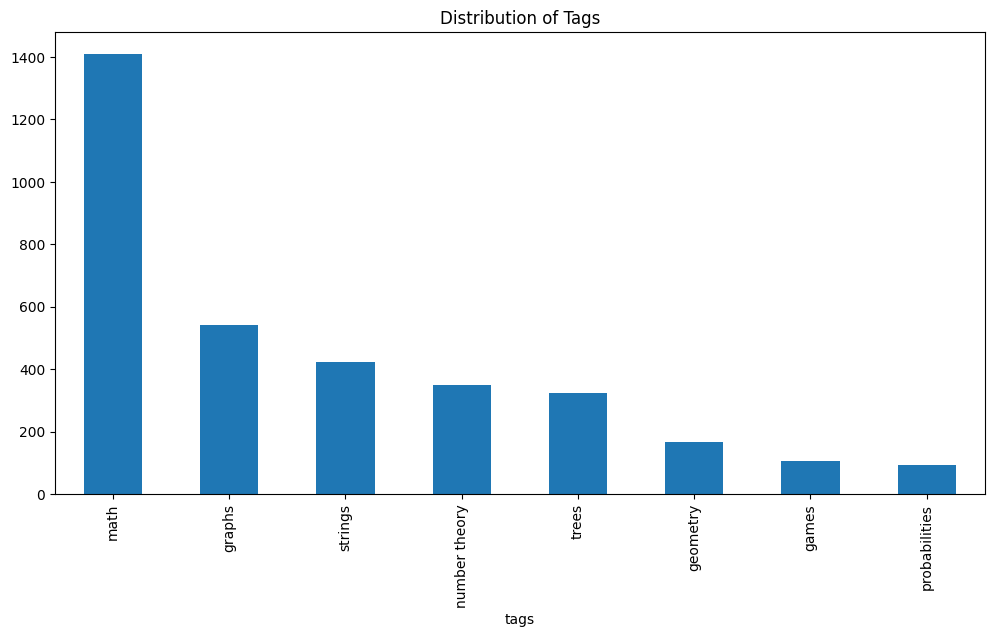

In [161]:
tag_stats(df)

### Analyse des variables numériques

#### Analyse univariée

In [162]:
df['prob_desc_time_limit'].value_counts()

prob_desc_time_limit
2 seconds      1222
1 second       1018
3 seconds       229
4 seconds        90
5 seconds        33
1.5 seconds      20
2.5 seconds      15
0.5 seconds      12
6 seconds        11
3.5 seconds       6
8 seconds         4
10 seconds        4
0.5 second        3
7 seconds         3
4.5 seconds       2
2 секунды         1
1 секунда         1
15 seconds        1
6.5 seconds       1
3.0 s             1
9 seconds         1
Name: count, dtype: int64

In [163]:
df['prob_desc_memory_limit'].value_counts()

prob_desc_memory_limit
256 megabytes     2408
512 megabytes      216
64 megabytes        30
1024 megabytes      11
128 megabytes        5
256 мегабайт         2
32 megabytes         2
384 megabytes        1
16 megabytes         1
768 megabytes        1
256 mebibytes        1
Name: count, dtype: int64

In [164]:
def extract_seconds(x):
    if pd.isna(x):
        return None
    match = re.search(r"([0-9.]+)", str(x))
    return float(match.group(1)) if match else None

In [165]:
def extract_memory(x):
    if pd.isna(x):
        return None
    match = re.search(r"([0-9]+)", str(x))
    return float(match.group(1)) if match else None

In [166]:
df["prob_desc_time_limit"] = df["prob_desc_time_limit"].apply(extract_seconds)

In [167]:
df['prob_desc_time_limit'].value_counts()

prob_desc_time_limit
2.0     1223
1.0     1019
3.0      230
4.0       90
5.0       33
1.5       20
0.5       15
2.5       15
6.0       11
3.5        6
8.0        4
10.0       4
7.0        3
4.5        2
15.0       1
6.5        1
9.0        1
Name: count, dtype: int64

In [168]:
df["prob_desc_memory_limit"] = df["prob_desc_memory_limit"].apply(extract_memory)

In [169]:
df['prob_desc_memory_limit'].value_counts()

prob_desc_memory_limit
256.0     2411
512.0      216
64.0        30
1024.0      11
128.0        5
32.0         2
384.0        1
16.0         1
768.0        1
Name: count, dtype: int64

C:\Users\amiri\AppData\Local\Temp\ipykernel_47784\2417630899.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\amiri\AppData\Local\Temp\ipykernel_47784\2417630899.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\amiri\AppData\Local\Temp\ipykernel_47784\24

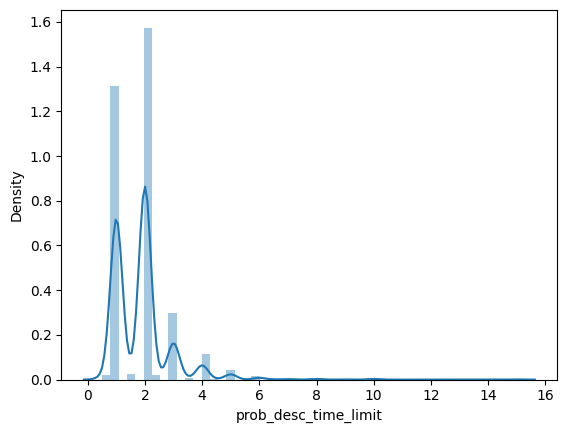

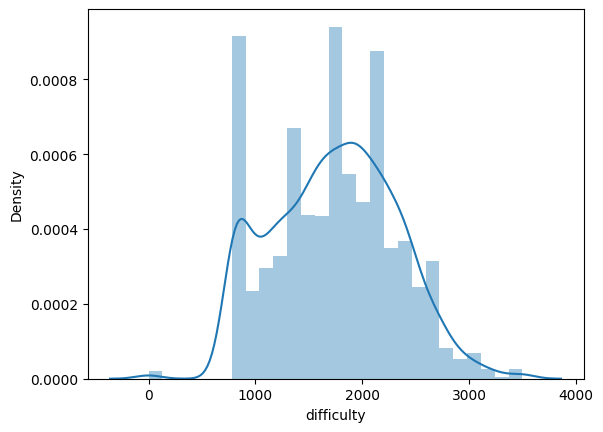

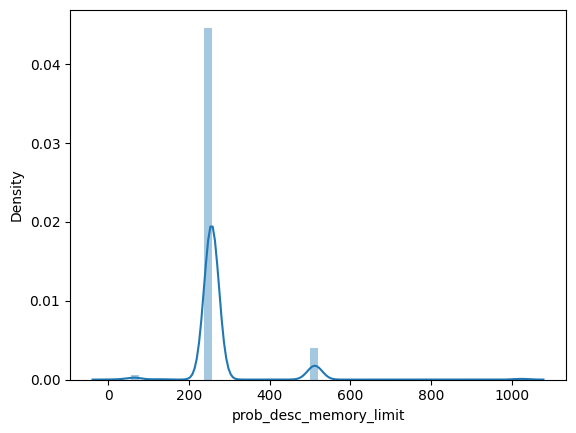

In [170]:
for col in df.select_dtypes('float'):
    plt.figure()
    sns.distplot(df[col])

**On peux enlever la colonne prob_desc_memory_limit**

In [171]:
df.drop(columns=['prob_desc_memory_limit'], inplace=True)

#### Relation variable-target

In [172]:
def plot_histograms_by_tag(df, col):
    df_tags = df.explode('tags')
    stats = df_tags.groupby('tags')[col].describe()
    display(stats)
    for tag in df_tags['tags'].unique():
        tag_df = df_tags[df_tags['tags'] == tag]
        plt.figure(figsize=(8,4))
        sns.histplot(tag_df[col], bins=20, kde=True)
        plt.title(f'Distribution of {col} for tag: {tag}')
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()

In [173]:
def plot_boxplot_by_tag(df, col):
    df_tags = df.explode('tags')
    df_tags_clean = df_tags.loc[:, ~df_tags.columns.duplicated()]  # Remove duplicate columns
    df_tags_clean = df_tags_clean.dropna(subset=['tags', col])  # Remove rows with missing tags or difficulty
    df_tags_clean['tags'] = df_tags_clean['tags'].astype(str)  # Ensure tags are strings

    plt.figure(figsize=(12,6))
    sns.boxplot(x='tags', y=col, data=df_tags_clean)
    plt.title(f'Boxplot of {col} by Tag')
    plt.xlabel('Tag')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.show()

* Le trait au milieu de la boîte : la médiane (valeur centrale de la distribution).
* Les extrémités de la boîte : le premier quartile (Q1, 25%) et le troisième quartile (Q3, 75%). La boîte montre l’intervalle interquartile (IQR = Q3 - Q1).
* Les « moustaches » (traits qui sortent de la boîte) : elles s’étendent jusqu’aux valeurs les plus extrêmes qui ne sont pas considérées comme des outliers, généralement jusqu’à Q1 - 1.5IQR et Q3 + 1.5IQR.
* Les points en dehors des moustaches : ce sont les outliers (valeurs atypiques, très éloignées du reste des données). 

,count,mean,std,min,25%,50%,75%,max
tags,,,,,,,,
games,102.0,1789.215686,606.712756,800.0,1300.0,1850.0,2275.0,3500.0
geometry,164.0,1925.000000,590.037433,800.0,1600.0,2000.0,2300.0,3500.0
graphs,541.0,2007.022181,450.590813,-1.0,1700.0,2000.0,2300.0,3500.0
math,1393.0,1630.506820,602.810936,-1.0,1100.0,1600.0,2100.0,3500.0
number theory,345.0,1786.086957,560.453557,800.0,1400.0,1800.0,2200.0,3500.0
probabilities,91.0,2236.263736,400.975611,1300.0,1900.0,2200.0,2500.0,3200.0
strings,420.0,1559.995238,527.375277,-1.0,1100.0,1500.0,2000.0,3200.0
trees,323.0,2054.179567,390.659013,900.0,1800.0,2000.0,2300.0,3100.0


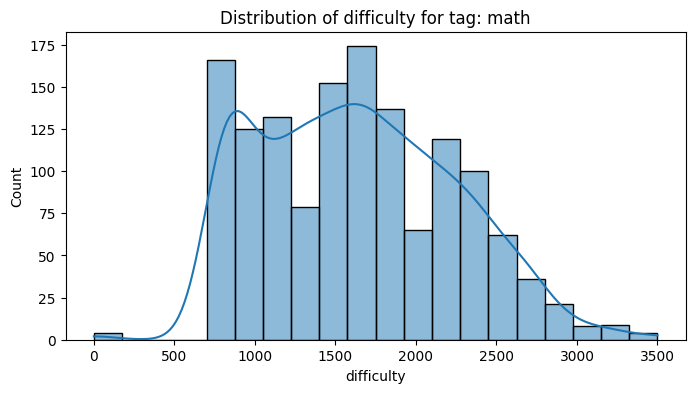

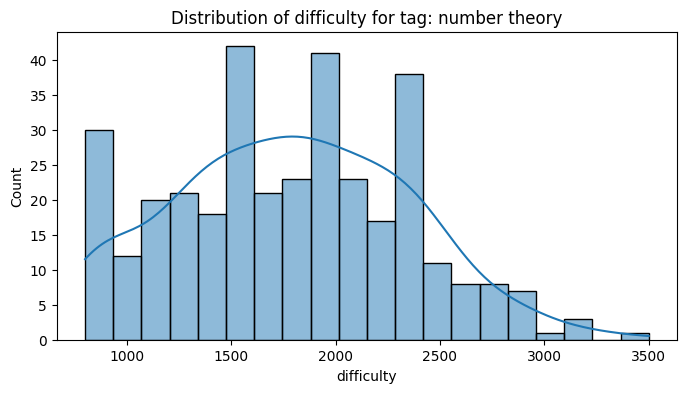

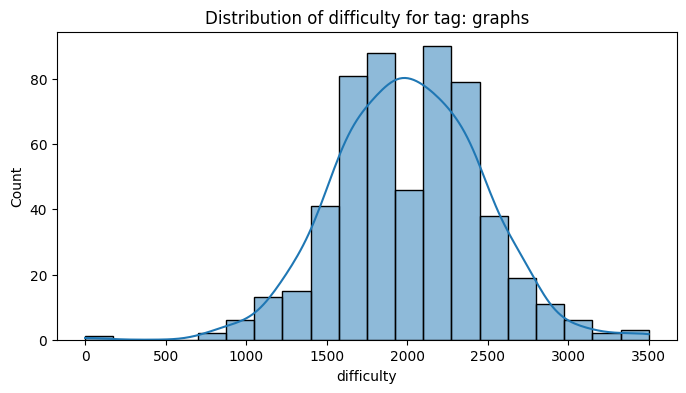

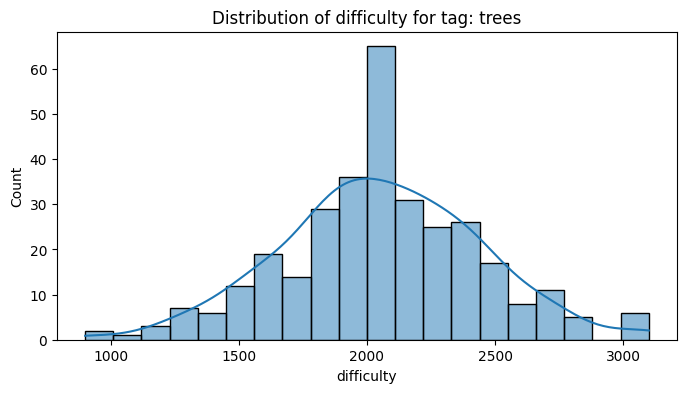

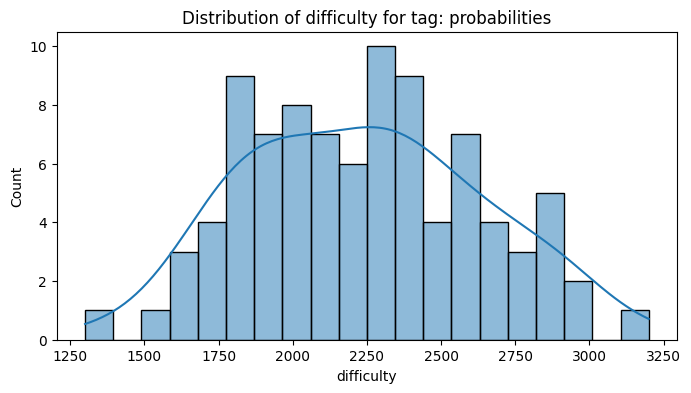

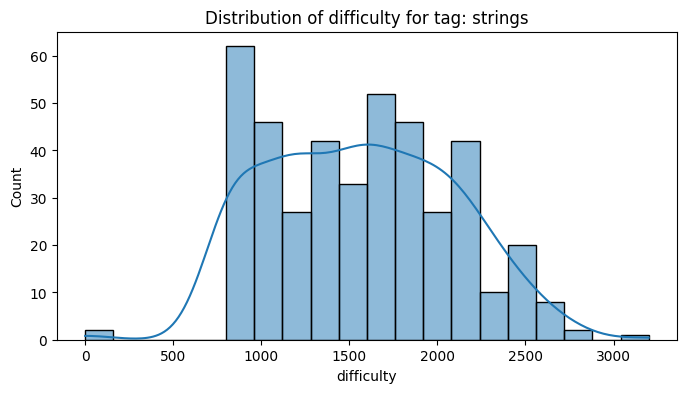

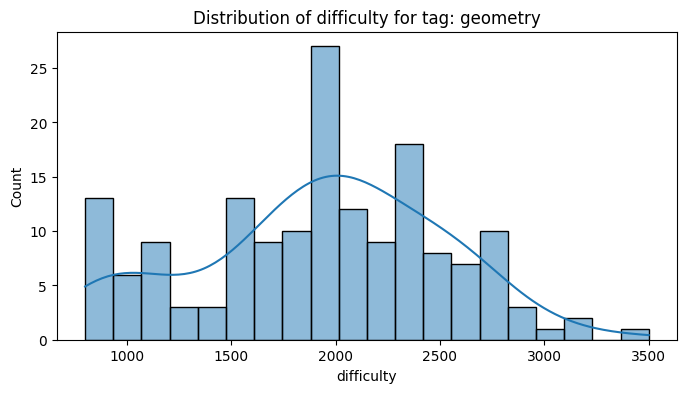

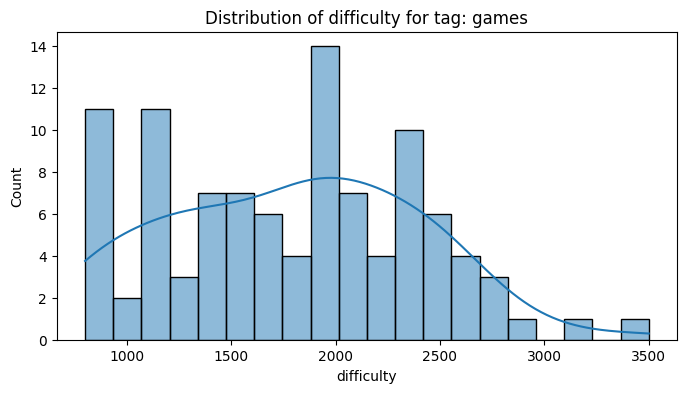

In [174]:
plot_histograms_by_tag(df, 'difficulty')

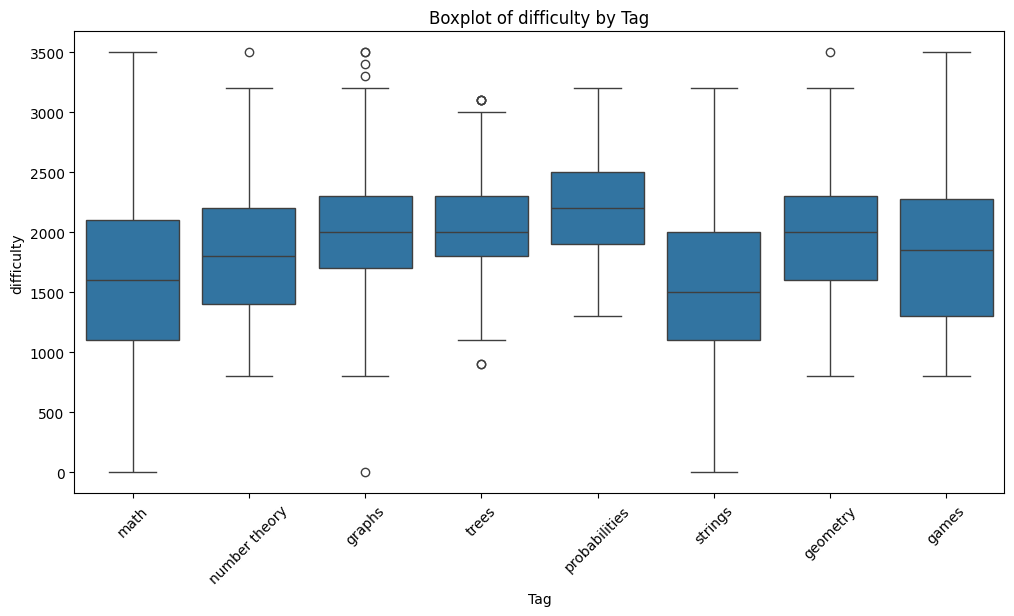

In [175]:
plot_boxplot_by_tag(df, 'difficulty')

,count,mean,std,min,25%,50%,75%,max
tags,,,,,,,,
games,105.0,1.752381,0.793979,1.0,1.0,2.0,2.0,5.0
geometry,166.0,1.837349,0.939402,0.5,1.0,2.0,2.0,8.0
graphs,542.0,2.146679,1.247614,1.0,1.0,2.0,2.0,15.0
math,1409.0,1.748048,0.973935,0.5,1.0,2.0,2.0,10.0
number theory,350.0,1.985714,1.180584,0.5,1.0,2.0,2.0,10.0
probabilities,92.0,2.266304,1.137404,0.5,2.0,2.0,2.5,7.0
strings,422.0,1.704976,0.739165,0.5,1.0,2.0,2.0,8.0
trees,324.0,2.200617,1.180282,1.0,2.0,2.0,2.0,10.0


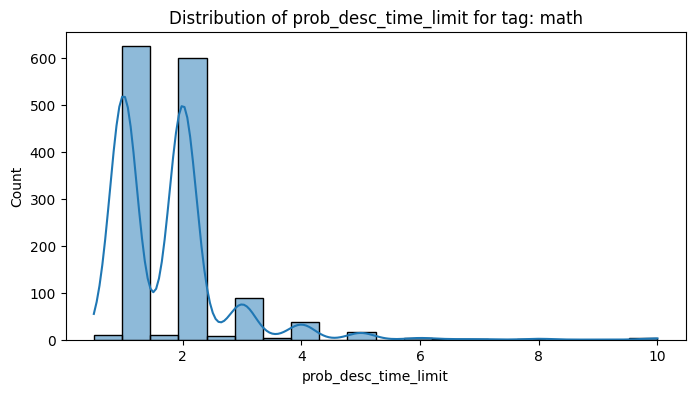

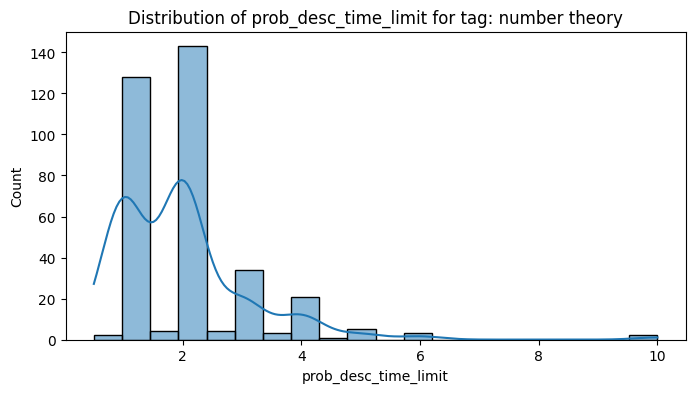

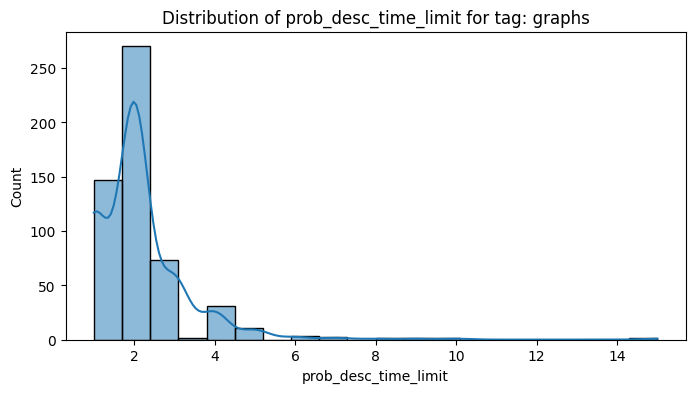

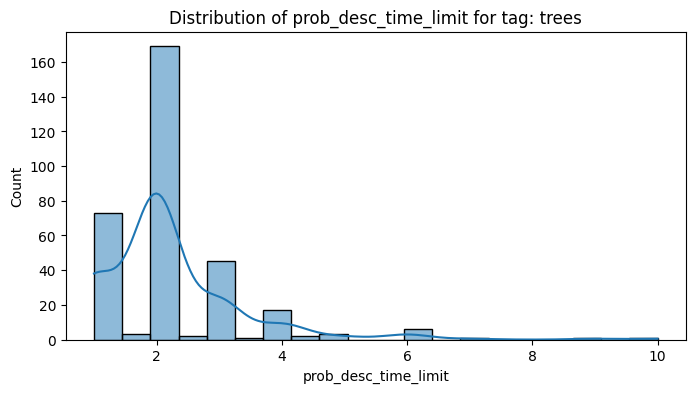

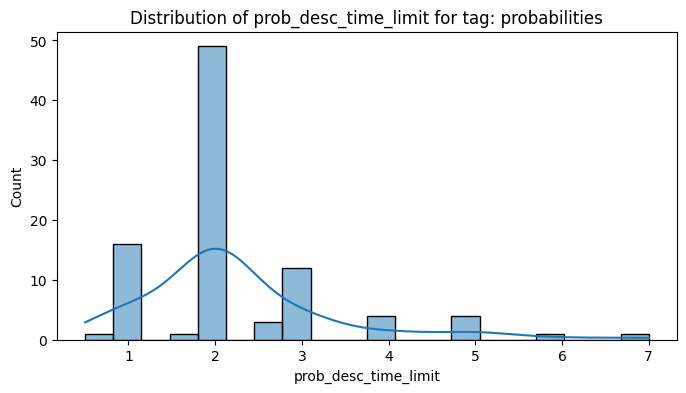

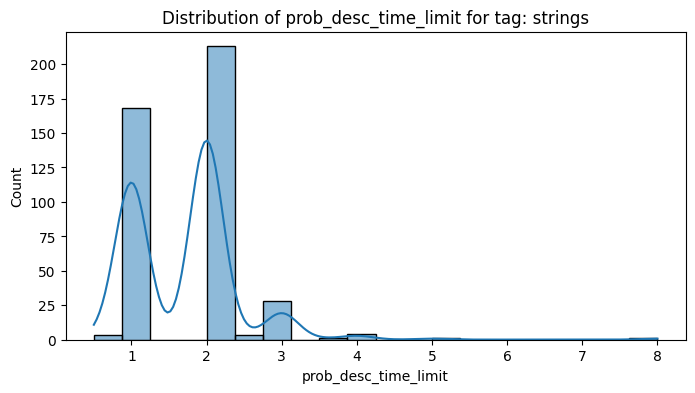

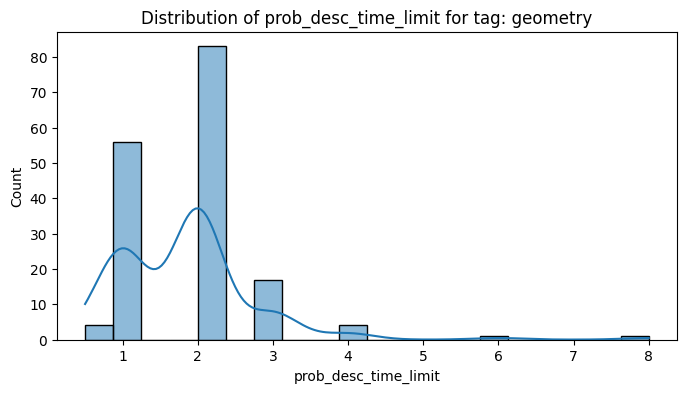

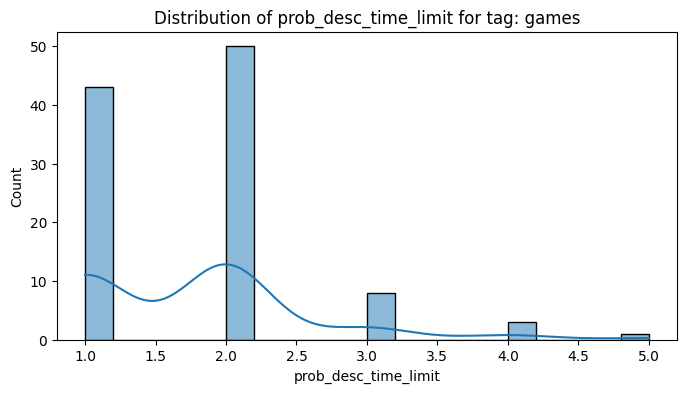

In [176]:
plot_histograms_by_tag(df, 'prob_desc_time_limit')

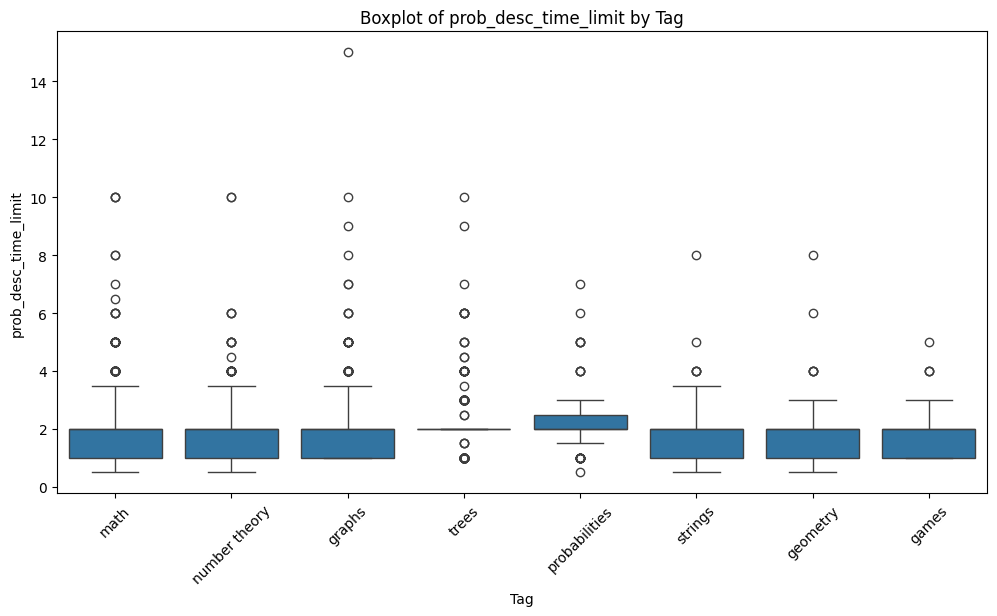

In [177]:
plot_boxplot_by_tag(df, 'prob_desc_time_limit')

**On peux supprimer la colonne prob_desc_time_limit**

In [178]:
df.drop(columns=['prob_desc_time_limit'], inplace=True)

### Analyse des variables textuelles

In [ ]:
text_columns = ["prob_desc_description", "prob_desc_input_spec", "prob_desc_output_spec", "ource_code"]

In [58]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
embedding_model = AutoModel.from_pretrained("microsoft/codebert-base")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15268.48it/s]


In [59]:
def extract_codebert_embeddings(text, tokenizer, model):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    tokens = tokenizer.tokenize(text)
    token_ids = inputs["input_ids"][0].tolist()
    with torch.no_grad():
        embeddings = model(**inputs).last_hidden_state.squeeze(0)
    return {
        "tokens": tokens,
        "token_ids": token_ids,
        "embeddings": embeddings
    }

#### Analyse univariée

##### Analyse de source_code

In [64]:
code_snippet = "def add(a, b): return a + b"
inputs = tokenizer(code_snippet, return_tensors="pt")
embeddings = embedding_model(**inputs).last_hidden_state  # embeddings du code
# Afficher les tokens extraits par le tokenizer CodeBERT
print("Tokens:", tokenizer.tokenize(code_snippet))
print("Token IDs:", inputs["input_ids"][0].tolist())

Tokens: ['def', 'Ġadd', '(', 'a', ',', 'Ġb', '):', 'Ġreturn', 'Ġa', 'Ġ+', 'Ġb']
Token IDs: [0, 9232, 1606, 1640, 102, 6, 741, 3256, 671, 10, 2055, 741, 2]


The token "Ġadd" appears this way because CodeBERT (and many other models based on the RoBERTa/BPE tokenizer) uses a special character (often "Ġ") to indicate the start of a new word or a space before the word. This helps the model distinguish between "add" at the start of a string and "add" in the middle of a sentence.

In [73]:
# Tester CodeBERT sur 100 exemples de source_code
column = "source_code"
sample_df = df[column].dropna().sample(n=1000, random_state=42)
results = sample_df.apply(lambda x: extract_codebert_embeddings(x, tokenizer, embedding_model))

In [74]:
results

1701    {'tokens': ['#', '!/', 'usr', '/', 'bin', '/',...
4163    {'tokens': ['from', 'Ġcollections', 'Ġimport',...
886     {'tokens': ['n', ',', 'Ġm', ',', 'Ġk', 'Ġ=', '...
1694    {'tokens': ['z', '=', 'input', 'Ċ', 'from', 'Ġ...
4809    {'tokens': ['n', 'Ġ=', 'Ġint', '(', 'input', '...
                              ...                        
1805    {'tokens': ['s', '0', 'Ġ=', 'Ġraw', '_', 'inpu...
2763    {'tokens': ['import', 'Ġsys', 'Ċ', 'range', 'Ġ...
2196    {'tokens': ['def', 'Ġfact', '(', 'x', '):', 'Ċ...
1124    {'tokens': ['n', 'Ġ=', 'Ġint', '(', 'input', '...
165     {'tokens': ['a', 'Ġ=', 'Ġint', '(', 'input', '...
Name: source_code, Length: 1000, dtype: object

c:\git_clones\tech_challenge_illuin_technology\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


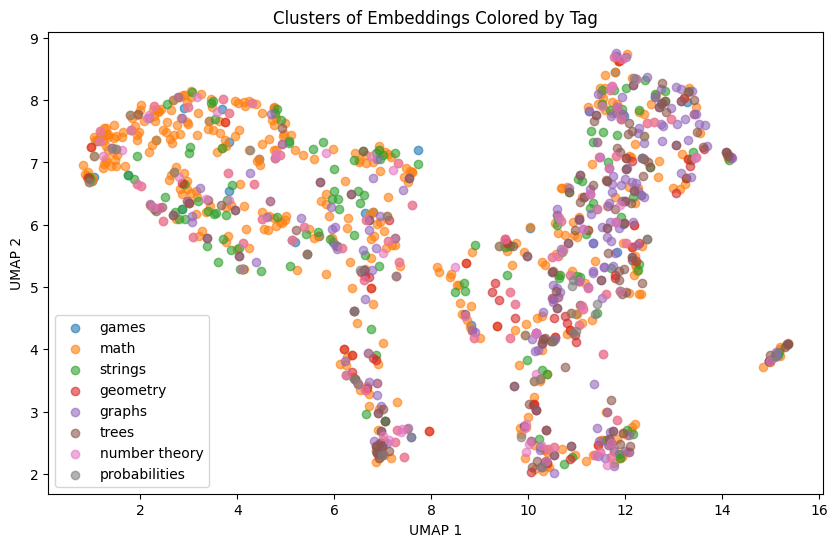

In [75]:
# 1. Extraire les embeddings moyens pour chaque exemple
embeddings = np.vstack([r['embeddings'].mean(dim=0).numpy() for r in results])

# 2. Récupérer les tags pour les exemples sélectionnés
tags_sample = df.loc[sample_df.index, 'tags']

# 3. Réduire la dimension
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d = reducer.fit_transform(embeddings)

# 4. Plot clusters colorés par tag
plt.figure(figsize=(10,6))
unique_tags = set([tag for tags_list in tags_sample for tag in tags_list])
for tag in unique_tags:
    idx = [i for i, tags_list in enumerate(tags_sample) if tag in tags_list]
    plt.scatter(embeddings_2d[idx,0], embeddings_2d[idx,1], label=tag, alpha=0.6)
plt.legend()
plt.title('Clusters of Embeddings Colored by Tag')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

In [ ]:
column = "source_code"
results = df[column].dropna().apply(lambda x: extract_codebert_embeddings(x, tokenizer, embedding_model))

In [ ]:
# Analyze token distribution
from collections import Counter
all_tokens = [token for r in results for token in r["tokens"]]
token_counts = Counter(all_tokens)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
top_tokens = token_counts.most_common(30)
tokens, counts = zip(*top_tokens)
plt.bar(tokens, counts)
plt.xticks(rotation=90)
plt.title("Top 30 Tokens in " + column)
plt.show()

In [143]:
tags_sample = df['tags']
unique_tags = set([tag for tags_list in tags_sample for tag in tags_list])

for tag_to_plot in unique_tags:
    # tag_presence est un Series booléen
    tag_presence = tags_sample.apply(lambda tags: tag_to_plot in tags)
    present_idx = tag_presence.values
    absent_idx = ~tag_presence.values

    plt.figure(figsize=(10,6))
    plt.scatter(
        embeddings_2d[present_idx, 0], embeddings_2d[present_idx, 1],
        c="red", label=f"{tag_to_plot} présent", alpha=0.6
    )
    plt.scatter(
        embeddings_2d[absent_idx, 0], embeddings_2d[absent_idx, 1],
        c="blue", label=f"{tag_to_plot} absent", alpha=0.3
    )
    plt.legend()
    plt.title(f"UMAP des embeddings - Présence du tag '{tag_to_plot}'")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 2678

<Figure size 1000x600 with 0 Axes>

#### Analyse de prob_desc_description

In [71]:
column = "prob_desc_description"
sample_df_desc = df[column].dropna().sample(n=1000, random_state=42)
results_desc = sample_df_desc.apply(lambda x: extract_codebert_embeddings(x, tokenizer, embedding_model))

c:\git_clones\tech_challenge_illuin_technology\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


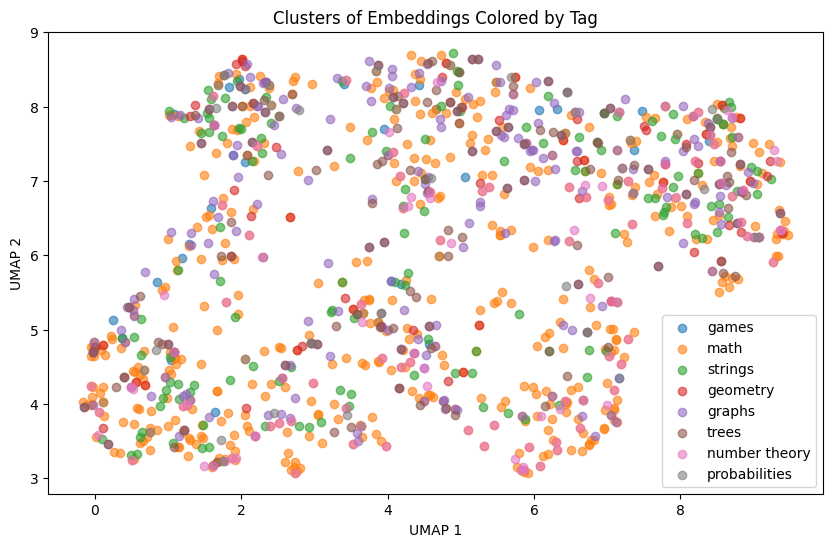

In [72]:
# 1. Extraire les embeddings moyens pour chaque exemple
embeddings_desc = np.vstack([r['embeddings'].mean(dim=0).numpy() for r in results_desc])

# 2. Récupérer les tags pour les exemples sélectionnés
tags_sample_desc = df.loc[sample_df_desc.index, 'tags']

# 3. Réduire la dimension
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d_desc = reducer.fit_transform(embeddings_desc)

# 4. Plot clusters colorés par tag
plt.figure(figsize=(10,6))
unique_tags_desc = set([tag for tags_list in tags_sample_desc for tag in tags_list])
for tag in unique_tags_desc:
    idx = [i for i, tags_list in enumerate(tags_sample_desc) if tag in tags_list]
    plt.scatter(embeddings_2d_desc[idx,0], embeddings_2d_desc[idx,1], label=tag, alpha=0.6)
plt.legend()
plt.title('Clusters of Embeddings Colored by Tag')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

#### Analyse de prob_desc_input_spec

In [ ]:
# Tester CodeBERT sur 1000 exemples de prob_desc_input_spec
column = "prob_desc_input_spec"
sample_df_input_spec = df[column].dropna().sample(n=1000, random_state=42)
results_input_spec = sample_df_input_spec.apply(lambda x: extract_codebert_embeddings(x, tokenizer, embedding_model))

In [ ]:
# 1. Extraire les embeddings moyens pour chaque exemple
embeddings_input_spec = np.vstack([r['embeddings'].mean(dim=0).numpy() for r in results_desc])

# 2. Récupérer les tags pour les exemples sélectionnés
tags_sample_input_spec = df.loc[sample_df_desc.index, 'tags']

# 3. Réduire la dimension
reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_2d_input_spec = reducer.fit_transform(embeddings_input_spec)

# 4. Plot clusters colorés par tag
plt.figure(figsize=(10,6))
unique_tags_input_spec = set([tag for tags_list in tags_sample_input_spec for tag in tags_list])
for tag in unique_tags_desc:
    idx = [i for i, tags_list in enumerate(tags_sample_input_spec) if tag in tags_list]
    plt.scatter(embeddings_2d_input_spec[idx,0], embeddings_2d_input_spec[idx,1], label=tag, alpha=0.6)
plt.legend()
plt.title('Clusters of Embeddings Colored by Tag')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.show()

In [79]:
df1=data.copy()

### TF-IDF

c:\git_clones\tech_challenge_illuin_technology\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


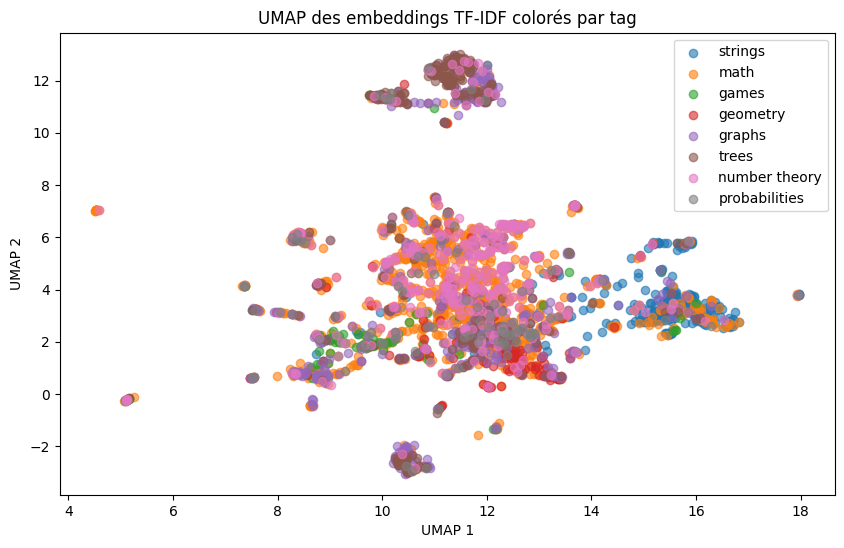

In [141]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Appliquer TF-IDF sur prob_desc_description
tfidf = TfidfVectorizer(max_features=512)
tfidf_matrix = tfidf.fit_transform(df['prob_desc_description'].fillna("")).toarray()

# 2. Réduire la dimension avec UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
tfidf_umap = reducer.fit_transform(tfidf_matrix)

# 3. Visualiser par tag
tags_sample = df['tags']
unique_tags = set([tag for tags_list in tags_sample for tag in tags_list])
plt.figure(figsize=(10,6))
for tag in unique_tags:
    idx = [i for i, tags_list in enumerate(tags_sample) if tag in tags_list]
    plt.scatter(tfidf_umap[idx,0], tfidf_umap[idx,1], label=tag, alpha=0.6)
plt.legend()
plt.title("UMAP des embeddings TF-IDF colorés par tag")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.show()

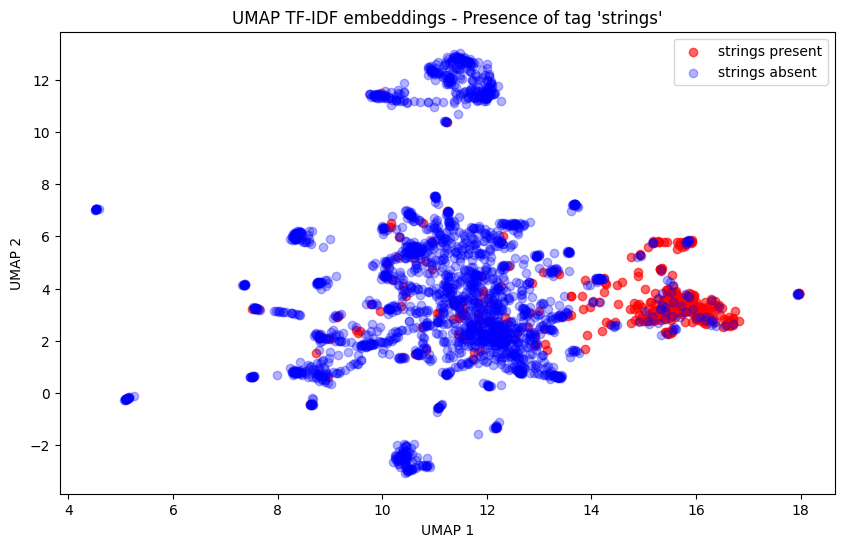

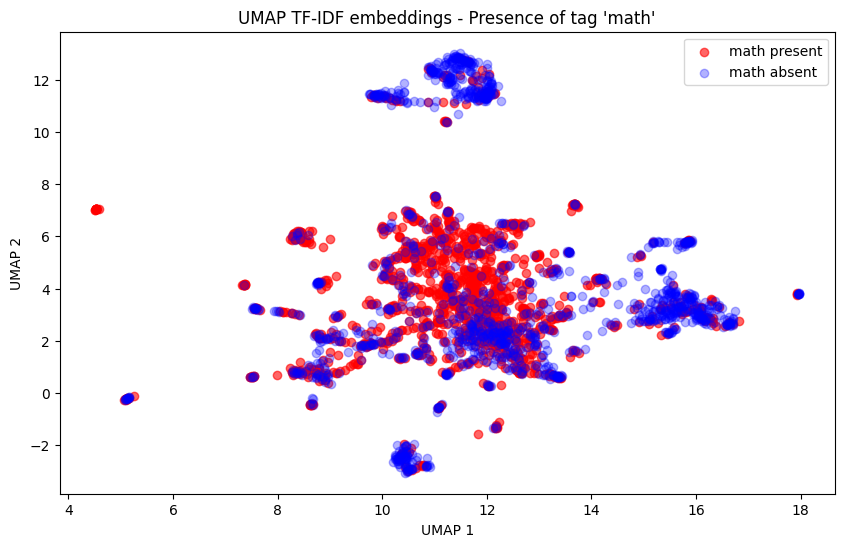

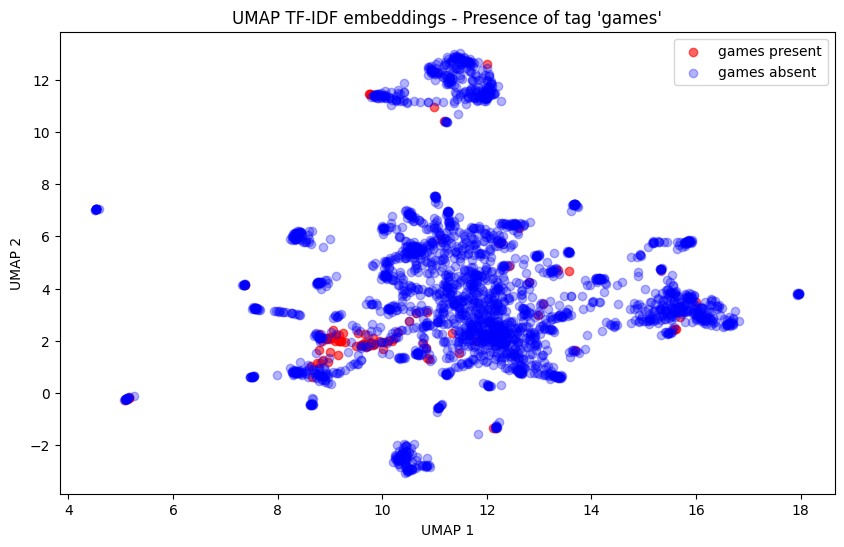

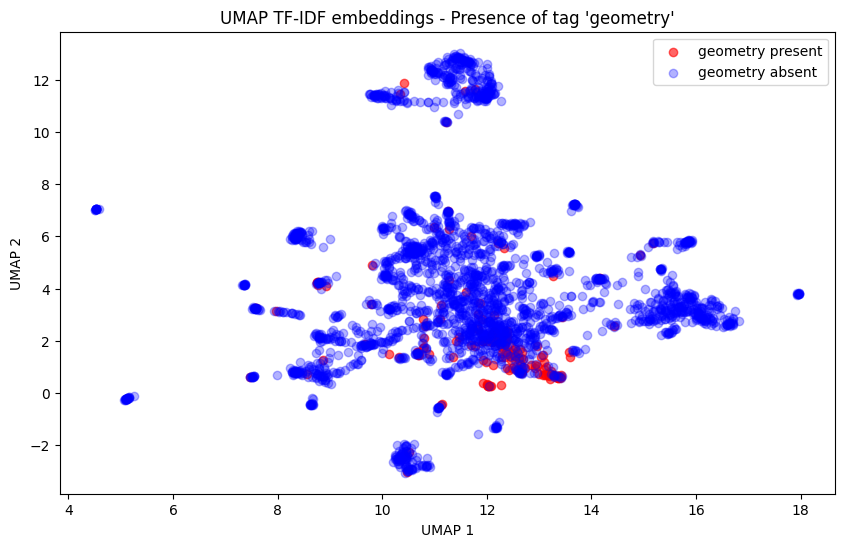

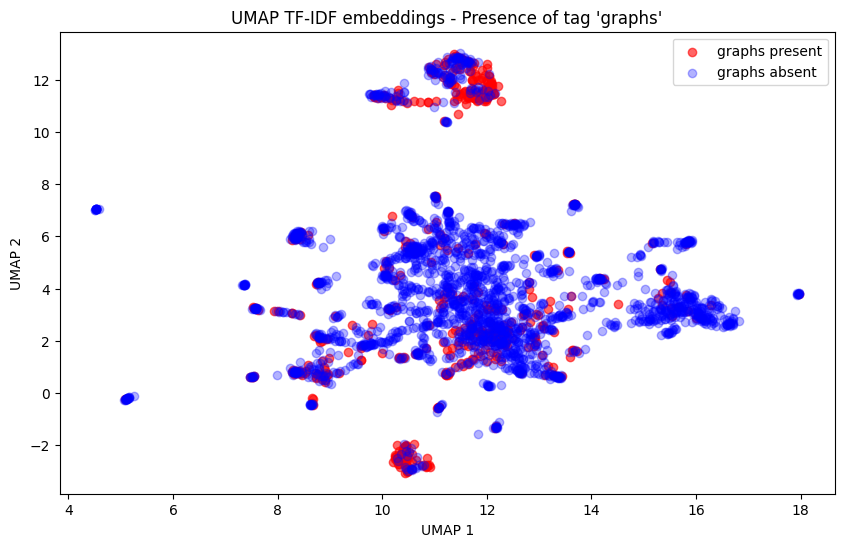

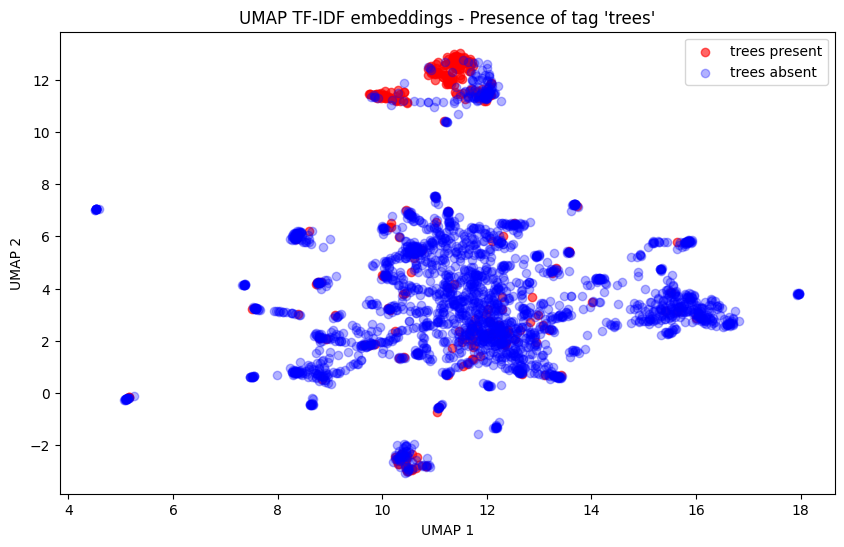

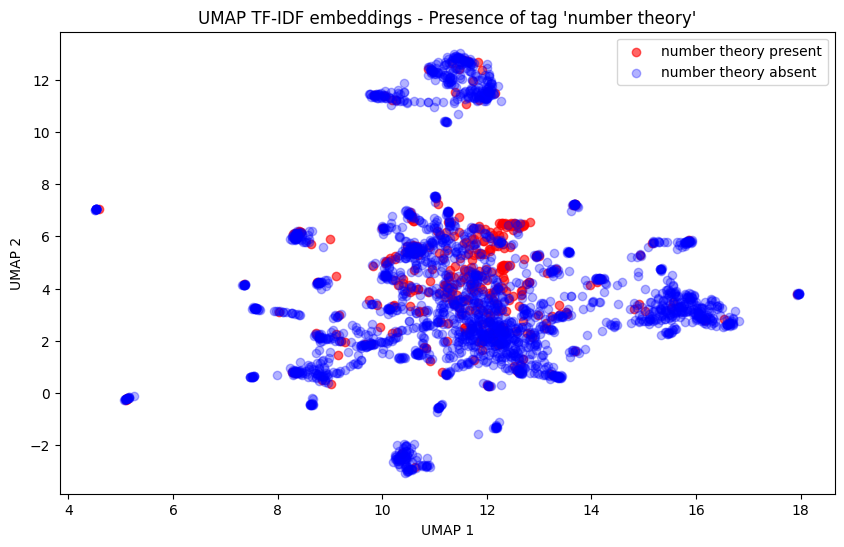

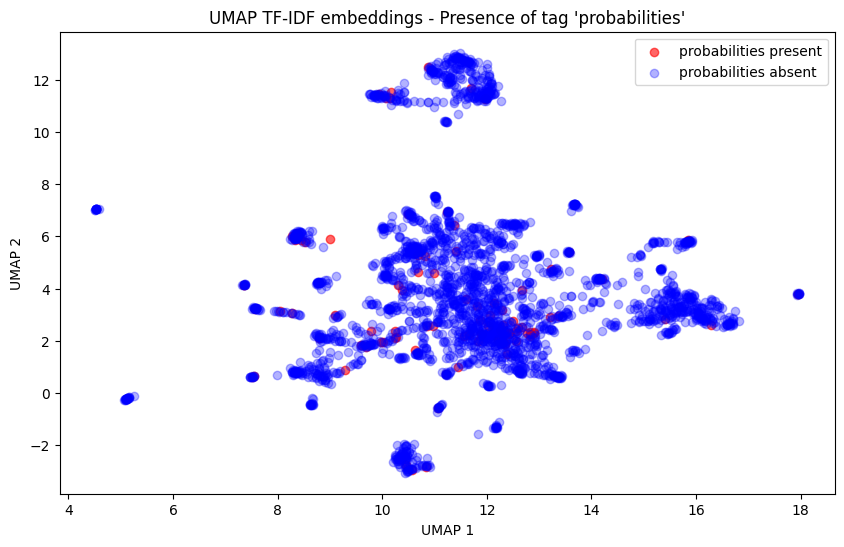

In [142]:
# tags_sample: list of tags per example
tags_sample = df['tags']
unique_tags = set([tag for tags_list in tags_sample for tag in tags_list])

for tag in unique_tags:
    tag_presence = tags_sample.apply(lambda tags: tag in tags)
    present_idx = tag_presence.values
    absent_idx = ~tag_presence.values

    plt.figure(figsize=(10,6))
    plt.scatter(
        tfidf_umap[present_idx, 0], tfidf_umap[present_idx, 1],
        c="red", label=f"{tag} present", alpha=0.6
    )
    plt.scatter(
        tfidf_umap[absent_idx, 0], tfidf_umap[absent_idx, 1],
        c="blue", label=f"{tag} absent", alpha=0.3
    )
    plt.legend()
    plt.title(f"UMAP TF-IDF embeddings - Presence of tag '{tag}'")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.show()

## Analyse plus détaillée

* Relation Variables / Variables 

## Enregistrer le dataset nettoyé

In [179]:
output_path = os.path.join(data_dir, 'dataset_cleaned.json')
df.to_json(output_path, orient='records', lines=True, force_ascii=False)
print(f"DataFrame enregistrée sous : {output_path}")

DataFrame enregistrée sous : c:\git_clones\tech_challenge_illuin_technology\data\dataset_cleaned.json
